In [ ]:
! git clone https://github.com/lanl/vision_transformers_explained.git

Cloning into 'vision_transformers_explained'...
remote: Enumerating objects: 240, done.
remote: Counting objects: 100% (65/65), done.
remote: Compressing objects: 100% (41/41), done.
remote: Total 240 (delta 29), reused 53 (delta 22), pack-reused 175 (from 1)
Receiving objects: 100% (240/240), 42.96 MiB | 17.97 MiB/s, done.
Resolving deltas: 100% (62/62), done.


#### Vision Transformers Explained Series

In [ ]:
import os
import copy
import math
import typing
import cv2
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import timm

In [ ]:
figure_path = '/content/vision_transformers_explained/figures/NotebookOutput'

In [ ]:
NoneFloat = typing.Union[None, float]

## Model Walk-Through



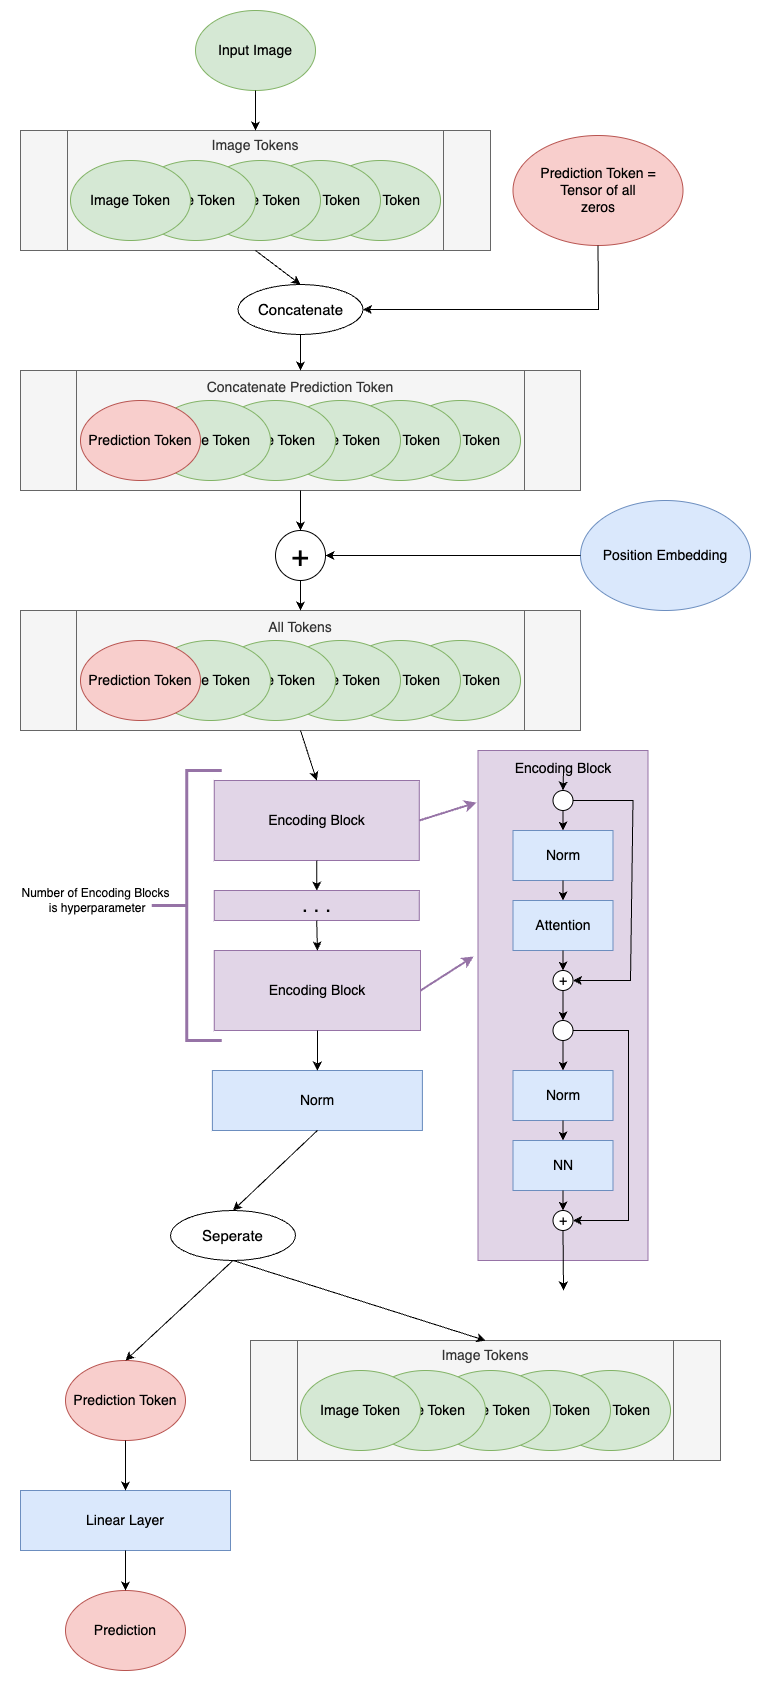

In [ ]:
from IPython.display import Image
Image('/content/vision_transformers_explained/figures/ModelDiagrams/ViT.png')


### Image Tokenization



Mountain at Dusk is H = 60 and W = 100 pixels.




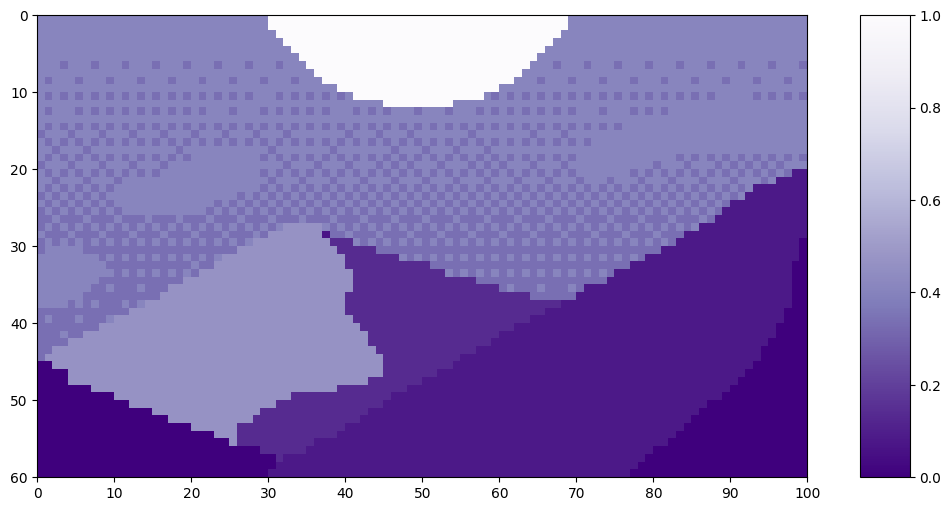

In [ ]:
mountains = np.load(os.path.join(figure_path, 'mountains.npy'))

H = mountains.shape[0]
W = mountains.shape[1]
print('Mountain at Dusk is H =', H, 'and W =', W, 'pixels.')
print('\n')

fig = plt.figure(figsize=(10,6))
plt.imshow(mountains, cmap='Purples_r')
plt.xticks(np.arange(-0.5, W+1, 10), labels=np.arange(0, W+1, 10))
plt.yticks(np.arange(-0.5, H+1, 10), labels=np.arange(0, H+1, 10))
plt.clim([0,1])
cbar_ax = fig.add_axes([0.95, .11, 0.05, 0.77])
plt.clim([0, 1])
plt.colorbar(cax=cbar_ax);
#plt.savefig(os.path.join(figure_path, 'mountains.png'), bbox_inches='tight')

This image has $H=60$ and $W=100$. We'll set $P=20$ since it divides both $H$ and $W$ evenly.

There will be 15 patches, each 20 by 20.




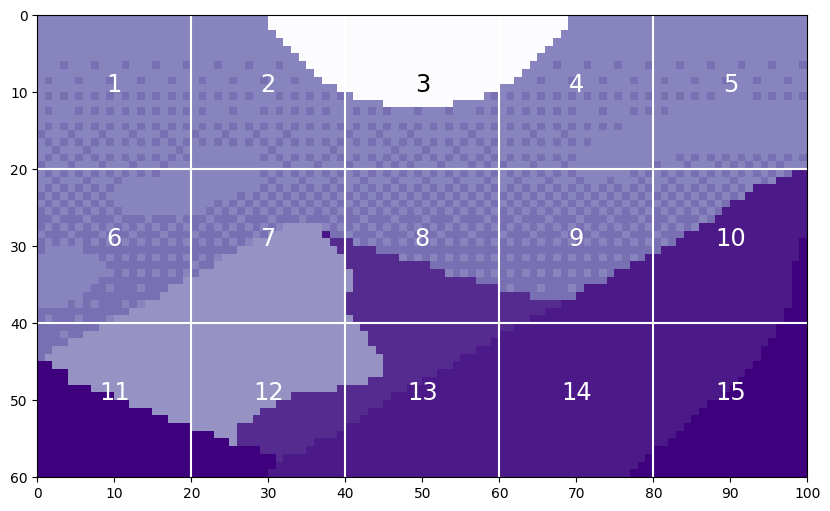

In [ ]:
P = 20
N = int((H*W)/(P**2))
print('There will be', N, 'patches, each', P, 'by', str(P)+'.')
print('\n')

fig = plt.figure(figsize=(10,6))
plt.imshow(mountains, cmap='Purples_r')
plt.clim([0,1])
plt.hlines(np.arange(P, H, P)-0.5, -0.5, W-0.5, color='w')
plt.vlines(np.arange(P, W, P)-0.5, -0.5, H-0.5, color='w')
plt.xticks(np.arange(-0.5, W+1, 10), labels=np.arange(0, W+1, 10))
plt.yticks(np.arange(-0.5, H+1, 10), labels=np.arange(0, H+1, 10))
x_text = np.tile(np.arange(9.5, W, P), 3)
y_text = np.repeat(np.arange(9.5, H, P), 5)
for i in range(1, N+1):
    plt.text(x_text[i-1], y_text[i-1], str(i), color='w', fontsize='xx-large', ha='center')
plt.text(x_text[2], y_text[2], str(3), color='k', fontsize='xx-large', ha='center');
#plt.savefig(os.path.join(figure_path, 'mountain_patches.png'), bbox_inches='tight')

By flattening these patches, we see the resulting tokens. Let's look at patch 6 as an example.

Each patch will make a token of length 400.




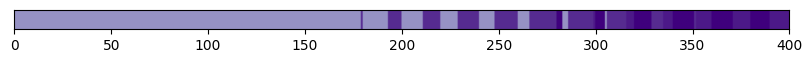

In [ ]:
print('Each patch will make a token of length', str(P**2)+'.')
print('\n')

patch12 = mountains[40:60, 20:40]
token12 = patch12.reshape(1, P**2)

fig = plt.figure(figsize=(10,1))
plt.imshow(token12, aspect=10, cmap='Purples_r')
plt.clim([0,1])
plt.xticks(np.arange(-0.5, 401, 50), labels=np.arange(0, 401, 50))
plt.yticks([]);
#plt.savefig(os.path.join(figure_path, 'mountain_token12.png'), bbox_inches='tight')

After extracting tokens from an image, it is common to use a linear projection to change the length of the tokens. This is implemented as a learnable linear layer. The new length of the tokens is referred to as the *latent dimension*², *channel dimension*³, or the *token length*. After the projection, the tokens are no longer visually identifiable as a patch from the original image.

Now that we understand the concept, we can look at how patch tokenization is implemented in code.

In [ ]:
class Patch_Tokenization(nn.Module):
    def __init__(self,
                img_size: tuple[int, int, int]=(1, 1, 60, 100),
                patch_size: int=50,
                token_len: int=768):

        """ Patch Tokenization Module
            Args:
                img_size (tuple[int, int, int]): size of input (channels, height, width)
                patch_size (int): the side length of a square patch
                token_len (int): desired length of an output token
        """
        super().__init__()

        ## Defining Parameters
        self.img_size = img_size
        C, H, W = self.img_size
        self.patch_size = patch_size
        self.token_len = token_len
        assert H % self.patch_size == 0, 'Height of image must be evenly divisible by patch size.'
        assert W % self.patch_size == 0, 'Width of image must be evenly divisible by patch size.'
        self.num_tokens = (H / self.patch_size) * (W / self.patch_size)

        ## Defining Layers
        self.split = nn.Unfold(kernel_size=self.patch_size, stride=self.patch_size, padding=0) #Split the Image Into Patches
        self.project = nn.Linear((self.patch_size**2)*C, token_len) #This means each of the 15 flattened patch vectors of size 400 is mapped to a 768-dimensional vector.

    def forward(self, x):
        x = self.split(x).transpose(1,0)
        x = self.project(x)
        return x

In [ ]:
x = torch.from_numpy(mountains).unsqueeze(0).unsqueeze(0).to(torch.float32)
token_len = 768 # hyperparameter commonly used in viT base
print('Input dimensions are\n\tbatchsize:', x.shape[0], '\n\tnumber of input channels:', x.shape[1], '\n\timage size:', (x.shape[2], x.shape[3]))

# Define the Module
patch_tokens = Patch_Tokenization(img_size=(x.shape[1], x.shape[2], x.shape[3]),
                                    patch_size = P,
                                    token_len = token_len)

Input dimensions are
	batchsize: 1 
	number of input channels: 1 
	image size: (60, 100)


Now, we'll split the image into tokens.

In [ ]:
x = patch_tokens.split(x).transpose(2,1)
print('After patch tokenization, dimensions are\n\tbatchsize:', x.shape[0], '\n\tnumber of tokens:', x.shape[1], '\n\ttoken length:', x.shape[2])

After patch tokenization, dimensions are
	batchsize: 1 
	number of tokens: 15 
	token length: 400


As we saw in the example, there are *N=15* tokens each of length 400. Lastly, we project the tokens to be the *token_len*.

In [ ]:
x = patch_tokens.project(x)
print('After projection, dimensions are\n\tbatchsize:', x.shape[0], '\n\tnumber of tokens:', x.shape[1], '\n\ttoken length:', x.shape[2])

After projection, dimensions are
	batchsize: 1 
	number of tokens: 15 
	token length: 768


Why This Matters
- Instead of pixels, the Transformer processes tokens.

- Unlike CNNs, ViTs do not rely on local spatial filters — self-attention allows global context from the start.

- This tokenizer helps bridge the gap between raw images and Transformers, making the image appear like a sequence of “words”.



### Token Processing

We'll designate the next two steps of the ViT, before the encoding blocks, as "token processing."

The first step is to prepend a blank token, called the *Prediction Token*, to the the image tokens. This token will be used at the output of the encoding blocks to make a prediction. It starts off blank - equivalently zero - so that it can gain information from the other image tokens.

We'll be starting with 175 tokens. Each token has length 768, which is the size for the base variant of ViT². We're using a batch size of 13 because it's prime and won't be confused for any of the other parameters.

In [ ]:
# Define an Input
num_tokens = 175 # 175 patches
token_len = 768
batch = 13
x = torch.rand(batch, num_tokens, token_len)
print('Input dimensions are\n\tbatchsize:', x.shape[0], '\n\tnumber of tokens:', x.shape[1], '\n\ttoken length:', x.shape[2])

# Append a Prediction Token
pred_token = torch.zeros(1, 1, token_len).expand(batch, -1, -1)
print('Prediction Token dimensions are\n\tbatchsize:', pred_token.shape[0], '\n\tnumber of tokens:', pred_token.shape[1], '\n\ttoken length:', pred_token.shape[2])

x = torch.cat((pred_token, x), dim=1)
print('Dimensions with Prediction Token are\n\tbatchsize:', x.shape[0], '\n\tnumber of tokens:', x.shape[1], '\n\ttoken length:', x.shape[2])

Input dimensions are
	batchsize: 13 
	number of tokens: 175 
	token length: 768
Prediction Token dimensions are
	batchsize: 13 
	number of tokens: 1 
	token length: 768
Dimensions with Prediction Token are
	batchsize: 13 
	number of tokens: 176 
	token length: 768


Now, we add a position embedding for our tokens. The position embedding allows the transformer to understand the order of the image tokens. Note that this is an addition, not a concatenation.

In [ ]:
def get_sinusoid_encoding(num_tokens, token_len):
    """ Make Sinusoid Encoding Table

        Args:
            num_tokens (int): number of tokens
            token_len (int): length of a token

        Returns:
            (torch.FloatTensor) sinusoidal position encoding table
    """

    def get_position_angle_vec(i):
        return [i / np.power(10000, 2 * (j // 2) / token_len) for j in range(token_len)]

    sinusoid_table = np.array([get_position_angle_vec(i) for i in range(num_tokens)])
    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])

    return torch.FloatTensor(sinusoid_table).unsqueeze(0)

PE = get_sinusoid_encoding(num_tokens+1, token_len)
print('Position embedding dimensions are\n\tnumber of tokens:', PE.shape[1], '\n\ttoken length:', PE.shape[2])

x = x + PE
print('Dimensions with Position Embedding are\n\tbatchsize:', x.shape[0], '\n\tnumber of tokens:', x.shape[1], '\n\ttoken length:', x.shape[2])

Position embedding dimensions are
	number of tokens: 176 
	token length: 768
Dimensions with Position Embedding are
	batchsize: 13 
	number of tokens: 176 
	token length: 768


Now, our tokens are ready to proceed to the encoding blocks.

### Encoding Block Prerequisite Code

The following code must be executed before the code in the *Encoding Block* section can be run.

In [ ]:
class Attention(nn.Module):
    def __init__(self,
                dim: int,
                chan: int,
                num_heads: int=1,
                qkv_bias: bool=False,
                qk_scale: NoneFloat=None):

        """ Attention Module

            Args:
                dim (int): input size of a single token
                chan (int): resulting size of a single token (channels)
                num_heads(int): number of attention heads in MSA (only works if =1)
                qkv_bias (bool): determines if the qkv layer learns an addative bias
                qk_scale (NoneFloat): value to scale the queries and keys by;
                                    if None, queries and keys are scaled by ``head_dim ** -0.5``
        """

        super().__init__()

        ## Define Constants
        self.num_heads = num_heads
        self.chan = chan
        self.head_dim = self.chan // self.num_heads
        self.scale = qk_scale or self.head_dim ** -0.5

        ## Define Layers
        self.qkv = nn.Linear(dim, chan * 3, bias=qkv_bias)
        ## Each token gets projected from starting token_len to channel length 3 times (once for each Q,K,V)
        self.proj = nn.Linear(chan, chan)

    def forward(self, x):
        if self.chan % self.num_heads != 0:
            raise ValueError('"Chan" must be evenly divisible by "num_heads".')
        B, N, C = x.shape
        ## Dimensions: (batch, num_tokens, token_len)

        ## Calcuate QKVs
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        ## Dimensions: (qkv, batch, heads, num_tokens, token_len = chan/num_heads = head_dim)
        q, k, v = qkv[0], qkv[1], qkv[2]

        ## Calculate Attention
        attn = (q * self.scale) @ k.transpose(-2, -1)
        attn = attn.softmax(dim=-1)
        ## Dimensions: (batch, heads, num_tokens, num_tokens)

        ## Attention Layer
        x = (attn @ v).transpose(1, 2).reshape(B, N, self.chan)
        ## Dimensions: (batch, heads, num_tokens, token_len = chan)

        ## Projection Layers
        x = self.proj(x)

        ## Skip Connection Layer
        v = v.transpose(1, 2).reshape(B, N, self.chan)
        x = v + x
        ## Because the original x has different size with current x, use v to do skip connection

        return x

### Encoding Block

The encoding block is where the model actually learns from the image tokens. The number of encoding blocks is a hyperparameter set by the user. A diagram of the encoding block is below.

In [ ]:
class Encoding(nn.Module):

    def __init__(self,
       dim: int,
       num_heads: int=1,
       hidden_chan_mul: float=4.,
       qkv_bias: bool=False,
       qk_scale: NoneFloat=None,
       act_layer=nn.GELU,
       norm_layer=nn.LayerNorm):

        """ Encoding Block

            Args:
                dim (int): size of a single token
                num_heads(int): number of attention heads in MSA
                hidden_chan_mul (float): multiplier to determine the number of hidden channels (features) in the NeuralNet component
                qkv_bias (bool): determines if the qkv layer learns an addative bias
                qk_scale (NoneFloat): value to scale the queries and keys by;
                                    if None, queries and keys are scaled by ``head_dim ** -0.5``
                act_layer(nn.modules.activation): torch neural network layer class to use as activation
                norm_layer(nn.modules.normalization): torch neural network layer class to use as normalization
        """

        super().__init__()

        ## Define Layers
        self.norm1 = norm_layer(dim)
        self.attn = Attention(dim=dim,
                            chan=dim,
                            num_heads=num_heads,
                            qkv_bias=qkv_bias,
                            qk_scale=qk_scale)
        self.norm2 = norm_layer(dim)
        self.neuralnet = NeuralNet(in_chan=dim,
                                hidden_chan=int(dim*hidden_chan_mul),
                                out_chan=dim,
                                act_layer=act_layer)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))      # First norm + attention + skip connection
        x = x + self.neuralnet(self.norm2(x)) # Second norm + neural net + skip connection
        return x

class NeuralNet(nn.Module):
  def __init__(self,
      in_chan: int,
      hidden_chan: NoneFloat=None,
      out_chan: NoneFloat=None,
      act_layer = nn.GELU):
      """ Neural Network Module

          Args:
              in_chan (int): number of channels (features) at input
              hidden_chan (NoneFloat): number of channels (features) in the hidden layer;
                                      if None, number of channels in hidden layer is the same as the number of input channels
              out_chan (NoneFloat): number of channels (features) at output;
                                      if None, number of output channels is same as the number of input channels
              act_layer(nn.modules.activation): torch neural network layer class to use as activation
      """

      super().__init__()

      ## Define Number of Channels
      hidden_chan = hidden_chan or in_chan
      out_chan = out_chan or in_chan

      ## Define Layers
      self.fc1 = nn.Linear(in_chan, hidden_chan)
      self.act = act_layer()
      self.fc2 = nn.Linear(hidden_chan, out_chan)

  def forward(self, x):
      x = self.fc1(x)
      x = self.act(x)
      x = self.fc2(x)
      return x

The *num_heads*, *qkv_bias*, and *qk_scale* parameters define the *Attention* module components.
The *hidden_chan_mul* and *act_layer* parameters define the *Neural Network* module components. T


We'll use 176 tokens of length 768. We'll use a batch size of 13 because it's prime and won't be confused for any of the other parameters. We'll use 4 attention heads because it evenly divides token length; however, you won't see the attention head dimension in the encoding block.

In [ ]:
# Define an Input
num_tokens = 176
token_len = 768
batch = 13
heads = 4
x = torch.rand(batch, num_tokens, token_len)
print('Input dimensions are\n\tbatchsize:', x.shape[0], '\n\tnumber of tokens:', x.shape[1], '\n\ttoken length:', x.shape[2])

# Define the Module
E = Encoding(dim=token_len, num_heads=heads, hidden_chan_mul=1.5, qkv_bias=False, qk_scale=None, act_layer=nn.GELU, norm_layer=nn.LayerNorm)
E.eval();

Input dimensions are
	batchsize: 13 
	number of tokens: 176 
	token length: 768


Now, we'll pass through a norm layer and an *Attention* module. The *Attention* module in the encoding block is parameterized so that it don't change the token length. After the *Attention module*, we implement our first split connection.

In [ ]:
y = E.norm1(x)
print('After norm, dimensions are\n\tbatchsize:', y.shape[0], '\n\tnumber of tokens:', y.shape[1], '\n\ttoken size:', y.shape[2])
y = E.attn(y)
print('After attention, dimensions are\n\tbatchsize:', y.shape[0], '\n\tnumber of tokens:', y.shape[1], '\n\ttoken size:', y.shape[2])
y = y + x
print('After split connection, dimensions are\n\tbatchsize:', y.shape[0], '\n\tnumber of tokens:', y.shape[1], '\n\ttoken size:', y.shape[2])

After norm, dimensions are
	batchsize: 13 
	number of tokens: 176 
	token size: 768
After attention, dimensions are
	batchsize: 13 
	number of tokens: 176 
	token size: 768
After split connection, dimensions are
	batchsize: 13 
	number of tokens: 176 
	token size: 768


Now, we pass through another norm layer, and then the *Neural Network* module. We finish with the second split connection.

In [ ]:
z = E.norm2(y)
print('After norm, dimensions are\n\tbatchsize:', z.shape[0], '\n\tnumber of tokens:', z.shape[1], '\n\ttoken size:', z.shape[2])
z = E.neuralnet(z)
print('After neural net, dimensions are\n\tbatchsize:', z.shape[0], '\n\tnumber of tokens:', z.shape[1], '\n\ttoken size:', z.shape[2])
z = z + y
print('After split connection, dimensions are\n\tbatchsize:', z.shape[0], '\n\tnumber of tokens:', z.shape[1], '\n\ttoken size:', z.shape[2])

After norm, dimensions are
	batchsize: 13 
	number of tokens: 176 
	token size: 768
After neural net, dimensions are
	batchsize: 13 
	number of tokens: 176 
	token size: 768
After split connection, dimensions are
	batchsize: 13 
	number of tokens: 176 
	token size: 768


That's all for a single encoding block! Since the final dimensions are the same as the initial dimensions, the model can easily pass tokens through multiple encoding blocks, as set by the *depth* hyperparameter.

### Neural Network Module

The *Neural Network* (NN) module is a sub-component of the encoding block. The NN module is very simple, consisting of a fully-connected layer, an activation layer, and another fully-connected layer. The activation layer can be any `torch.nn.modules.activation`⁷ layer, which is passed as input to the module. The NN module can be configured to change the shape of an input, or to maintain the same shape. We're not going to step through this code, as neural networks are common in machine learning, and not the focus of this article. However, the code for the NN module is presented below.

In [ ]:
class NeuralNet(nn.Module):
    def __init__(self,
       in_chan: int,
       hidden_chan: NoneFloat=None,
       out_chan: NoneFloat=None,
       act_layer = nn.GELU):
        """ Neural Network Module

            Args:
                in_chan (int): number of channels (features) at input
                hidden_chan (NoneFloat): number of channels (features) in the hidden layer;
                                        if None, number of channels in hidden layer is the same as the number of input channels
                out_chan (NoneFloat): number of channels (features) at output;
                                        if None, number of output channels is same as the number of input channels
                act_layer(nn.modules.activation): torch neural network layer class to use as activation
        """

        super().__init__()

        ## Define Number of Channels
        hidden_chan = hidden_chan or in_chan
        out_chan = out_chan or in_chan

        ## Define Layers
        self.fc1 = nn.Linear(in_chan, hidden_chan)
        self.act = act_layer()
        self.fc2 = nn.Linear(hidden_chan, out_chan)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.fc2(x)
        return x

### Prediction Processing

After passing through the encoding blocks, the last thing the model must do is make a prediction. The "prediction processing" component of the ViT diagram is shown below.

We're going to look at each step of this process. We'll continue with 176 tokens of length 768. We'll use a  batch size of 1 to illustrate how a single prediction is made. A batch size greater than 1 would be computing this prediction in parallel.

In [ ]:
# Define an Input
num_tokens = 176
token_len = 768
batch = 1
x = torch.rand(batch, num_tokens, token_len)
print('Input dimensions are\n\tbatchsize:', x.shape[0], '\n\tnumber of tokens:', x.shape[1], '\n\ttoken length:', x.shape[2])

Input dimensions are
	batchsize: 1 
	number of tokens: 176 
	token length: 768


First, all the tokens are passed through a norm layer.

In [ ]:
norm = nn.LayerNorm(token_len)
x = norm(x)
print('After norm, dimensions are\n\tbatchsize:', x.shape[0], '\n\tnumber of tokens:', x.shape[1], '\n\ttoken size:', x.shape[2])

After norm, dimensions are
	batchsize: 1 
	number of tokens: 176 
	token size: 768


Next, we split off the prediction token from the rest of the tokens. Throughout the encoding block(s), the prediction token has become nonzero and gained information about our input image. We'll use only this prediction token to make a final prediction.

In [ ]:
pred_token = x[:, 0]
print('Length of prediction token:', pred_token.shape[-1])

Length of prediction token: 768


In [ ]:
head = nn.Linear(token_len, 1)
pred = head(pred_token)
print('Length of prediction:', (pred.shape[0], pred.shape[1]))
print('Prediction:', float(pred))

Length of prediction: (1, 1)
Prediction: 0.6448608040809631


## cat vs dog


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shaunthesheep/microsoft-catsvsdogs-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/microsoft-catsvsdogs-dataset


In [ ]:
import os
import torch
import torch.nn as nn
from torchvision import datasets, transforms

from torchvision.datasets import ImageFolder
from torchvision.transforms import ToTensor
from torchvision.utils import make_grid
from torch.optim import Adam
from tqdm import tqdm
import matplotlib.pyplot as plt
import timm

from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.datasets import ImageFolder
from torchvision import transforms

from PIL import Image, UnidentifiedImageError
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [ ]:
class CustomDataset(Dataset):
    def __init__(self, img_paths, labels, transform=None):
        self.img_paths = img_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        try:
            img = Image.open(self.img_paths[idx]).convert('RGB')
        except UnidentifiedImageError:
            print(f"Warning: Skipping corrupted image {self.img_paths[idx]}")
            # Create dummy black image
            img = Image.new('RGB', (128, 128), (0, 0, 0))
            label = self.labels[idx]
        else:
            label = self.labels[idx]

        if self.transform:
            img = self.transform(img)

        return img, label


In [ ]:
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader, random_split
from glob import glob
data_dir = "/kaggle/input/microsoft-catsvsdogs-dataset/PetImages"
class_names = sorted(os.listdir(data_dir))
img_paths, labels = [], []

for label_idx, class_name in enumerate(class_names):
    class_dir = os.path.join(data_dir, class_name)
    image_files = glob(os.path.join(class_dir, '*.jpg'))
    img_paths.extend(image_files)
    labels.extend([label_idx] * len(image_files))

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])  # Normalize to [-1, 1]
])


dataset = CustomDataset(img_paths, labels, transform=transform)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

In [ ]:
class Patch_Tokenization(nn.Module):
    def __init__(self,
                img_size: tuple[int, int, int]=(1, 1, 60, 100),
                patch_size: int=50,
                token_len: int=768):

        """ Patch Tokenization Module
            Args:
                img_size (tuple[int, int, int]): size of input (channels, height, width)
                patch_size (int): the side length of a square patch
                token_len (int): desired length of an output token
        """
        super().__init__()

        ## Defining Parameters
        self.img_size = img_size
        C, H, W = self.img_size
        self.patch_size = patch_size
        self.token_len = token_len
        assert H % self.patch_size == 0, 'Height of image must be evenly divisible by patch size.'
        assert W % self.patch_size == 0, 'Width of image must be evenly divisible by patch size.'
        self.num_tokens = (H / self.patch_size) * (W / self.patch_size)

        ## Defining Layers
        self.split = nn.Unfold(kernel_size=self.patch_size, stride=self.patch_size, padding=0) #Split the Image Into Patches
        self.project = nn.Linear((self.patch_size**2)*C, token_len) #This means each of the 15 flattened patch vectors of size 400 is mapped to a 768-dimensional vector.

    def forward(self, x):
        x = self.split(x)
        # print("Before transpose:", x.shape)  # Should be [32, 3072, 16]
        x = x.transpose(1, 2)
        # print("After transpose:", x.shape)   # Should be [32, 16, 3072]
        x = self.project(x)
        return x


In [ ]:
class ViT_Backbone(nn.Module): # token processing -> encoding -> prediciton
    def __init__(self,
                preds: int=1,
                token_len: int=768,
                num_heads: int=1,
                Encoding_hidden_chan_mul: float=4.,
                depth: int=12,
                qkv_bias=False,
                qk_scale=None,
                act_layer=nn.GELU,
                norm_layer=nn.LayerNorm,
                num_tokens=None):

        """ VisTransformer Backbone
            Args:
                preds (int): number of predictions to output
                token_len (int): length of a token
                num_heads(int): number of attention heads in MSA
                Encoding_hidden_chan_mul (float): multiplier to determine the number of hidden channels (features) in the NeuralNet component of the Encoding Module
                depth (int): number of encoding blocks in the model
                qkv_bias (bool): determines if the qkv layer learns an addative bias
                qk_scale (NoneFloat): value to scale the queries and keys by;
                 if None, queries and keys are scaled by ``head_dim ** -0.5``
                act_layer(nn.modules.activation): torch neural network layer class to use as activation
                norm_layer(nn.modules.normalization): torch neural network layer class to use as normalization
        """

        super().__init__()

        ## Defining Parameters
        self.num_heads = num_heads
        self.Encoding_hidden_chan_mul = Encoding_hidden_chan_mul
        self.depth = depth
        self.token_len = token_len
        self.num_tokens = int(num_tokens)

        ## Defining Token Processing Components
        self.cls_token = nn.Parameter(torch.zeros(1, 1, self.token_len))
        self.pos_embed = nn.Parameter(data=get_sinusoid_encoding(num_tokens=self.num_tokens+1, token_len=self.token_len), requires_grad=False)

        ## Defining Encoding blocks
        self.blocks = nn.ModuleList([Encoding(dim = self.token_len,
                                               num_heads = self.num_heads,
                                               hidden_chan_mul = self.Encoding_hidden_chan_mul,
                                               qkv_bias = qkv_bias,
                                               qk_scale = qk_scale,
                                               act_layer = act_layer,
                                               norm_layer = norm_layer)
             for i in range(self.depth)])

        ## Defining Prediction Processing
        self.norm = norm_layer(self.token_len)
        self.head = nn.Linear(self.token_len, preds)

        ## Make the class token sampled from a truncated normal distrobution
        timm.layers.trunc_normal_(self.cls_token, std=.02)

    def forward(self, x):
        ## Assumes x is already tokenized

        ## Get Batch Size
        B = x.shape[0]
        ## Concatenate Class Token
        x = torch.cat((self.cls_token.expand(B, -1, -1), x), dim=1)
        ## Add Positional Embedding
        x = x + self.pos_embed
        ## Run Through Encoding Blocks
        for blk in self.blocks:
            x = blk(x)
        ## Take Norm
        x = self.norm(x)
        ## Make Prediction on Class Token
        x = self.head(x[:, 0])
        return x

In [ ]:
class ViT_Model(nn.Module):
    def __init__(self,
                img_size: tuple[int, int, int]=(1, 400, 100),
                patch_size: int=50,
                token_len: int=768,
                preds: int=1,
                num_heads: int=1,
                Encoding_hidden_chan_mul: float=4.,
                depth: int=12,
                qkv_bias=False,
                qk_scale=None,
                act_layer=nn.GELU,
                norm_layer=nn.LayerNorm):

        """ VisTransformer Model
            Args:
                img_size (tuple[int, int, int]): size of input (channels, height, width)
                patch_size (int): the side length of a square patch
                token_len (int): desired length of an output token
                preds (int): number of predictions to output
                num_heads(int): number of attention heads in MSA
                Encoding_hidden_chan_mul (float): multiplier to determine the number of hidden channels (features) in the NeuralNet component of the Encoding Module
                depth (int): number of encoding blocks in the model
                qkv_bias (bool): determines if the qkv layer learns an addative bias
                qk_scale (NoneFloat): value to scale the queries and keys by;
                                    if None, queries and keys are scaled by ``head_dim ** -0.5``
                act_layer(nn.modules.activation): torch neural network layer class to use as activation
                norm_layer(nn.modules.normalization): torch neural network layer class to use as normalization
        """
        super().__init__()

        ## Defining Parameters
        self.img_size = img_size
        C, H, W = self.img_size
        self.patch_size = patch_size
        self.token_len = token_len
        self.num_heads = num_heads
        self.Encoding_hidden_chan_mul = Encoding_hidden_chan_mul
        self.depth = depth

        ## Defining Patch Embedding Module
        self.patch_tokens = Patch_Tokenization(img_size,
        patch_size,
        token_len)

        ## Defining ViT Backbone
        self.backbone = ViT_Backbone(
            preds=preds,
            token_len=token_len,
            num_heads=num_heads,
            Encoding_hidden_chan_mul=Encoding_hidden_chan_mul,
            depth=depth,
            qkv_bias=qkv_bias,
            qk_scale=qk_scale,
            act_layer=act_layer,
            norm_layer=norm_layer,
            num_tokens=self.patch_tokens.num_tokens  # ✅ new argument
        )

        ## Initialize the Weights
        self.apply(self._init_weights)

    def _init_weights(self, m):
        """ Initialize the weights of the linear layers & the layernorms
        """
        ## For Linear Layers
        if isinstance(m, nn.Linear):
            ## Weights are initialized from a truncated normal distrobution
            timm.layers.trunc_normal_(m.weight, std=.02)
            if isinstance(m, nn.Linear) and m.bias is not None:
                ## If bias is present, bias is initialized at zero
                nn.init.constant_(m.bias, 0)
        ## For Layernorm Layers
        elif isinstance(m, nn.LayerNorm):
            ## Weights are initialized at one
            nn.init.constant_(m.weight, 1.0)
            ## Bias is initialized at zero
            nn.init.constant_(m.bias, 0)

    @torch.jit.ignore ##Tell pytorch to not compile as TorchScript
    def no_weight_decay(self):
        """ Used in Optimizer to ignore weight decay in the class token
        """
        return {'cls_token'}

    def forward(self, x):
        x = self.patch_tokens(x)
        x = self.backbone(x)
        return x

In [ ]:
model = ViT_Model(
    img_size=(3, 224, 224),  # Update to match new resized shape
    patch_size=16,           # Make sure patch_size divides 128 evenly
    token_len=768,
    preds=2,
    num_heads=8,
    depth=6
).to(device)
# Initialize weights
def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

model.apply(init_weights)

ViT_Model(
  (patch_tokens): Patch_Tokenization(
    (split): Unfold(kernel_size=16, dilation=1, padding=0, stride=16)
    (project): Linear(in_features=768, out_features=768, bias=True)
  )
  (backbone): ViT_Backbone(
    (blocks): ModuleList(
      (0-3): 4 x Encoding(
        (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=False)
          (proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (neuralnet): NeuralNet(
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (act): GELU(approximate='none')
          (fc2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
    )
    (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (head): Linear(in_features=768, out_features=2, bias=True)
  )
)

In [ ]:
# Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=3e-4)

def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10):
    train_acc, val_acc = [], []

    for epoch in range(epochs):
        model.train()
        total, correct = 0, 0
        for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            imgs, labels = imgs.to(device), labels.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        acc = 100 * correct / total
        train_acc.append(acc)

        # Validation
        model.eval()
        total, correct = 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        val_accuracy = 100 * correct / total
        val_acc.append(val_accuracy)

        print(f"Train Acc: {acc:.2f}%, Val Acc: {val_accuracy:.2f}%")

    return train_acc, val_acc

train_acc, val_acc = train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10)


Epoch 1/20:  36%|███▌      | 224/625 [01:18<02:19,  2.87it/s]

Epoch 1/20:  58%|█████▊    | 360/625 [02:04<01:30,  2.93it/s]

Epoch 1/20: 100%|██████████| 625/625 [03:36<00:00,  2.89it/s]
/usr/local/lib/python3.11/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Train Acc: 52.70%, Val Acc: 60.58%


Epoch 2/20:   4%|▍         | 28/625 [00:10<03:24,  2.92it/s]

...

Train Acc: 56.56%, Val Acc: 52.86%


Epoch 20/20:  31%|███       | 194/625 [01:05<02:21,  3.04it/s]

Epoch 20/20:  80%|████████  | 502/625 [02:47<00:40,  3.06it/s]

Epoch 20/20: 100%|██████████| 625/625 [03:29<00:00,  2.99it/s]
/usr/local/lib/python3.11/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Train Acc: 55.73%, Val Acc: 56.30%


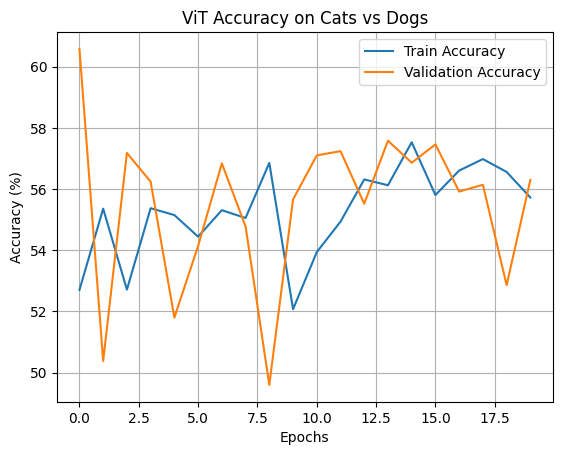

In [ ]:
plt.plot(train_acc, label="Train Accuracy")
plt.plot(val_acc, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("ViT Accuracy on Cats vs Dogs")
plt.legend()
plt.grid(True)
plt.show()


# Pros and Cons of ViT Compared to CNN-Based Architectures
## Pros of Vision Transformer (ViT):
- Global Context Modeling: ViTs use self-attention to capture global relationships between all patches in the image from the very first layer, unlike CNNs which are inherently local.

- Scalability: ViTs scale better with large datasets and computational resources, often outperforming CNNs on large-scale datasets when pre-trained extensively.

- Architectural Simplicity: The design of ViT avoids convolutions entirely, relying on linear projections and attention, which can be more flexible for research.

## Cons of Vision Transformer (ViT):
- Data-Hungry: ViTs require large amounts of labeled data to train effectively. They underperform on small datasets without pretraining or strong regularization.

- Computationally Expensive: The self-attention mechanism has quadratic complexity with respect to the number of image patches, making ViTs more memory- and compute-intensive than CNNs.

- Lack of Inductive Bias: CNNs benefit from strong inductive biases like locality and translation invariance, which ViTs lack, making them less efficient in learning with limited data.

